In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# =========================
# IMPORTS & DEPENDENCIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, GRU
from tensorflow.keras.optimizers import Adam, Nadam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import holidays


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import holidays

# =========================
# 1. LOAD
# =========================
df = pd.read_excel("/content/drive/MyDrive/Diploma/RawData/all_clean+more_weather.xlsx", header=None)

df.columns = [
    'date', 'hour_range', 'forecast', 'actual',
    'temperature_2m', 'relative_humidity_2m', 'weather_code',
    'cloud_cover', 'wind_speed_10m', 'dew_point_2m',
    'apparent_temperature', 'surface_pressure', 'wind_speed_100m',
    'wind_direction_10m', 'soil_temperature_0_to_7cm',
    'soil_moisture_0_to_7cm'
]

df['is_date'] = df['date'].astype(str).str.match(r'\d{4}-\d{2}-\d{2}')
df['date'] = df['date'].where(df['is_date']).ffill()

df = df[pd.to_numeric(df['actual'], errors='coerce').notnull()].copy()

df['hour'] = df['hour_range'].str.split('--').str[0].astype(int)
df['datetime'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='h')

df = df.sort_values('datetime').reset_index(drop=True)

# =========================
# 2. TIME FEATURES
# =========================
df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)

df['dow'] = df['datetime'].dt.dayofweek
df['dow_sin'] = np.sin(2*np.pi*df['dow']/7)
df['dow_cos'] = np.cos(2*np.pi*df['dow']/7)

df['month'] = df['datetime'].dt.month
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

# =========================
# 3. HOLIDAYS
# =========================
ru_holidays = holidays.Russia(years=df['datetime'].dt.year.unique())

df['is_weekend'] = df['dow'].isin([5,6]).astype(int)
df['is_holiday'] = df['datetime'].dt.date.apply(lambda x: int(x in ru_holidays))
df['is_special_day'] = ((df['is_weekend'] + df['is_holiday']) > 0).astype(int)

# =========================
# 4. LAGS + ROLLING (only past info)
# =========================
df['lag_1'] = df['actual'].shift(1)
df['lag_24'] = df['actual'].shift(24)
df['lag_168'] = df['actual'].shift(168)

df['roll_24'] = df['actual'].shift(1).rolling(24).mean()
df['roll_168'] = df['actual'].shift(1).rolling(168).mean()

# =========================
# 5. FEATURES
# =========================
weather_features = [
    'temperature_2m','relative_humidity_2m','cloud_cover',
    'wind_speed_10m','surface_pressure','apparent_temperature',
    'dew_point_2m','wind_speed_100m','soil_temperature_0_to_7cm',
    'weather_code','wind_direction_10m','soil_moisture_0_to_7cm'
]

features = [
    'hour_sin','hour_cos',
    'dow_sin','dow_cos',
    'month_sin','month_cos',
    'is_special_day',
    'lag_1','lag_24','lag_168',
    'roll_24','roll_168'
] + weather_features

target = 'actual'

# =========================
# 6. CLEAN
# =========================
df = df.dropna().reset_index(drop=True)

# =========================
# 7. TIME SPLIT (NO LEAKAGE)
# =========================
n = len(df)

train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_df = df[:train_end].copy()
val_df = df[train_end:val_end].copy()
test_df = df[val_end:].copy()

# =========================
# 8. SCALING (FIT ONLY ON TRAIN)
# =========================
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_raw = scaler_X.fit_transform(train_df[features])
X_val_raw = scaler_X.transform(val_df[features])
X_test_raw = scaler_X.transform(test_df[features])

y_train_raw = scaler_y.fit_transform(train_df[[target]])
y_val_raw = scaler_y.transform(val_df[[target]])
y_test_raw = scaler_y.transform(test_df[[target]])

# =========================
# 9. SEQUENCE BUILDER
# =========================
LOOKBACK = 168   # 7 days
HORIZON = 24      # next day

def create_sequences(X, y, lookback=168, horizon=24):
    Xs, ys = [], []
    for i in range(len(X) - lookback - horizon):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback:i+lookback+horizon])
    return np.array(Xs), np.array(ys)

# =========================
# 10. BUILD SETS
# =========================
X_train, y_train = create_sequences(X_train_raw, y_train_raw, LOOKBACK, HORIZON)
X_val, y_val = create_sequences(X_val_raw, y_val_raw, LOOKBACK, HORIZON)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, LOOKBACK, HORIZON)

# =========================
# 11. SHAPES CHECK
# =========================
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

/tmp/ipykernel_1562/1948181312.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['date'] = df['date'].where(df['is_date']).ffill()


X_train: (22051, 168, 24)
y_train: (22051, 24, 1)
X_val: (4574, 168, 24)
y_val: (4574, 24, 1)
X_test: (4575, 168, 24)
y_test: (4575, 24, 1)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

n_features = X_train.shape[2]

LOOKBACK = X_train.shape[1]
HORIZON = y_train.shape[1]

# =========================
# MODEL: ENCODER-DECODER LSTM
# =========================
model = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),

    # -------- Encoder --------
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.2),

    # -------- Bridge --------
    layers.RepeatVector(HORIZON),

    # -------- Decoder --------
    layers.LSTM(128, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(64, return_sequences=True),

    layers.TimeDistributed(layers.Dense(32, activation='relu')),
    layers.TimeDistributed(layers.Dense(1))
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

model.summary()

# =========================
# CALLBACKS
# =========================
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

# =========================
# TRAIN
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# =========================
# PREDICT
# =========================
y_pred = model.predict(X_test)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        78,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 24, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 24, 32)         │         2,080 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 1)          │            33 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 261,441 (1021.25 KB)

 Trainable params: 261,441 (1021.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0049 - mae: 0.0485 - val_loss: 0.0023 - val_mae: 0.0390 - learning_rate: 0.0010
Epoch 2/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - loss: 0.0012 - mae: 0.0267 - val_loss: 0.0013 - val_mae: 0.0293 - learning_rate: 0.0010
Epoch 3/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 0.0010 - mae: 0.0244 - val_loss: 4.9994e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 4/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - loss: 8.5373e-04 - mae: 0.0225 - val_loss: 5.0189e-04 - val_mae: 0.0171 - learning_rate: 0.0010
Epoch 5/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 7.7870e-04 - mae: 0.0215 - val_loss: 5.2097e-04 - val_mae: 0.0175 - learning_rate: 0.0010
Epoch 6/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 7.3873e-04 - mae: 0.0209 - val_loss: 4.7842e-04 - val_mae: 0.0166 - learning_rate: 0.0010
Epoch 7/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 7.2232e-04 - mae: 0.0206 - val_loss: 3.9256e-0

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. INVERSE SCALE
# =========================
y_test_inv = scaler_y.inverse_transform(
    y_test.reshape(-1, 1)
).reshape(y_test.shape)

y_pred_inv = scaler_y.inverse_transform(
    y_pred.reshape(-1, 1)
).reshape(y_pred.shape)

# =========================
# 2. FLATTENED METRICS (global)
# =========================
y_true_flat = y_test_inv.flatten()
y_pred_flat = y_pred_inv.flatten()

mae = mean_absolute_error(y_true_flat, y_pred_flat)
rmse = np.sqrt(mean_squared_error(y_true_flat, y_pred_flat))

mape = np.mean(np.abs((y_true_flat - y_pred_flat) / (y_true_flat + 1e-8))) * 100

smape = np.mean(
    2.0 * np.abs(y_pred_flat - y_true_flat) /
    (np.abs(y_true_flat) + np.abs(y_pred_flat) + 1e-8)
) * 100

print("\n===== GLOBAL METRICS =====")
print(f"MAE   : {mae:.4f}")
print(f"RMSE  : {rmse:.4f}")
print(f"MAPE  : {mape:.2f}%")
print(f"sMAPE : {smape:.2f}%")

# =========================
# 3. PER-HORIZON METRICS (T+1 ... T+24)
# =========================
horizon = y_test.shape[1]

mae_per_t = []
rmse_per_t = []
mape_per_t = []

for t in range(horizon):
    yt = y_test_inv[:, t, 0]
    yp = y_pred_inv[:, t, 0]

    mae_t = mean_absolute_error(yt, yp)
    rmse_t = np.sqrt(mean_squared_error(yt, yp))
    mape_t = np.mean(np.abs((yt - yp) / (yt + 1e-8))) * 100

    mae_per_t.append(mae_t)
    rmse_per_t.append(rmse_t)
    mape_per_t.append(mape_t)

print("\n===== PER-HORIZON METRICS =====")
for t in range(horizon):
    print(
        f"T+{t+1:02d}h | "
        f"MAE: {mae_per_t[t]:.3f} | "
        f"RMSE: {rmse_per_t[t]:.3f} | "
        f"MAPE: {mape_per_t[t]:.2f}%"
    )

# =========================
# 4. SUMMARY INSIGHT (useful for analysis)
# =========================
print("\n===== SUMMARY =====")
print(f"Best step (MAE): T+{np.argmin(mae_per_t)+1}")
print(f"Worst step (MAE): T+{np.argmax(mae_per_t)+1}")


===== GLOBAL METRICS =====
MAE   : 1333.3994
RMSE  : 1805.4319
MAPE  : 2.21%
sMAPE : 2.22%

===== PER-HORIZON METRICS =====
T+01h | MAE: 1033.876 | RMSE: 1348.368 | MAPE: 1.71%
T+02h | MAE: 1038.712 | RMSE: 1365.277 | MAPE: 1.72%
T+03h | MAE: 1076.185 | RMSE: 1412.509 | MAPE: 1.79%
T+04h | MAE: 1076.992 | RMSE: 1429.581 | MAPE: 1.78%
T+05h | MAE: 1098.938 | RMSE: 1471.052 | MAPE: 1.82%
T+06h | MAE: 1114.841 | RMSE: 1504.070 | MAPE: 1.85%
T+07h | MAE: 1141.326 | RMSE: 1543.559 | MAPE: 1.90%
T+08h | MAE: 1166.527 | RMSE: 1579.712 | MAPE: 1.94%
T+09h | MAE: 1190.313 | RMSE: 1612.772 | MAPE: 1.98%
T+10h | MAE: 1213.835 | RMSE: 1648.357 | MAPE: 2.01%
T+11h | MAE: 1242.443 | RMSE: 1687.704 | MAPE: 2.06%
T+12h | MAE: 1276.296 | RMSE: 1729.981 | MAPE: 2.12%
T+13h | MAE: 1310.353 | RMSE: 1772.320 | MAPE: 2.17%
T+14h | MAE: 1344.921 | RMSE: 1814.950 | MAPE: 2.23%
T+15h | MAE: 1380.724 | RMSE: 1858.404 | MAPE: 2.28%
T+16h | MAE: 1418.659 | RMSE: 1902.092 | MAPE: 2.35%
T+17h | MAE: 1459.239 | RMS

In [ ]:
# =========================
# 6. BASELINE: SEASONAL NAIVE (CORRECT)
# =========================

target_values = df[target].values

y_baseline = []

# индексы тестовых таргетов соответствуют последовательностям y_test
# нужно восстановить реальные временные индексы
test_start_idx = val_end + LOOKBACK

for i in range(len(y_test)):
    seq = []

    for t in range(HORIZON):
        idx = test_start_idx + i + t
        lag_idx = idx - 24

        if lag_idx >= 0:
            seq.append(target_values[lag_idx])
        else:
            seq.append(np.nan)

    y_baseline.append(seq)

y_baseline = np.array(y_baseline).reshape(y_test.shape)
# =========================
# 7. BASELINE METRICS (CORRECT)
# =========================

# приводим к inverse scale уже если baseline в нормализованном виде
# (у тебя baseline уже в оригинале → scaling НЕ нужен)

y_baseline_flat = y_baseline.flatten()
y_true_flat = y_test_inv.flatten()

mae_baseline = mean_absolute_error(y_true_flat, y_baseline_flat)
rmse_baseline = np.sqrt(mean_squared_error(y_true_flat, y_baseline_flat))

mape_baseline = np.mean(
    np.abs((y_true_flat - y_baseline_flat) / (y_true_flat + 1e-8))
) * 100

smape_baseline = np.mean(
    2.0 * np.abs(y_baseline_flat - y_true_flat) /
    (np.abs(y_true_flat) + np.abs(y_baseline_flat) + 1e-8)
) * 100

print("\n===== BASELINE (SEASONAL NAIVE - LAG 24) =====")
print(f"MAE   : {mae_baseline:.4f}")
print(f"RMSE  : {rmse_baseline:.4f}")
print(f"MAPE  : {mape_baseline:.2f}%")
print(f"sMAPE : {smape_baseline:.2f}%")


===== BASELINE (SEASONAL NAIVE - LAG 24) =====
MAE   : 1930.1022
RMSE  : 2700.2627
MAPE  : 3.21%
sMAPE : 3.21%


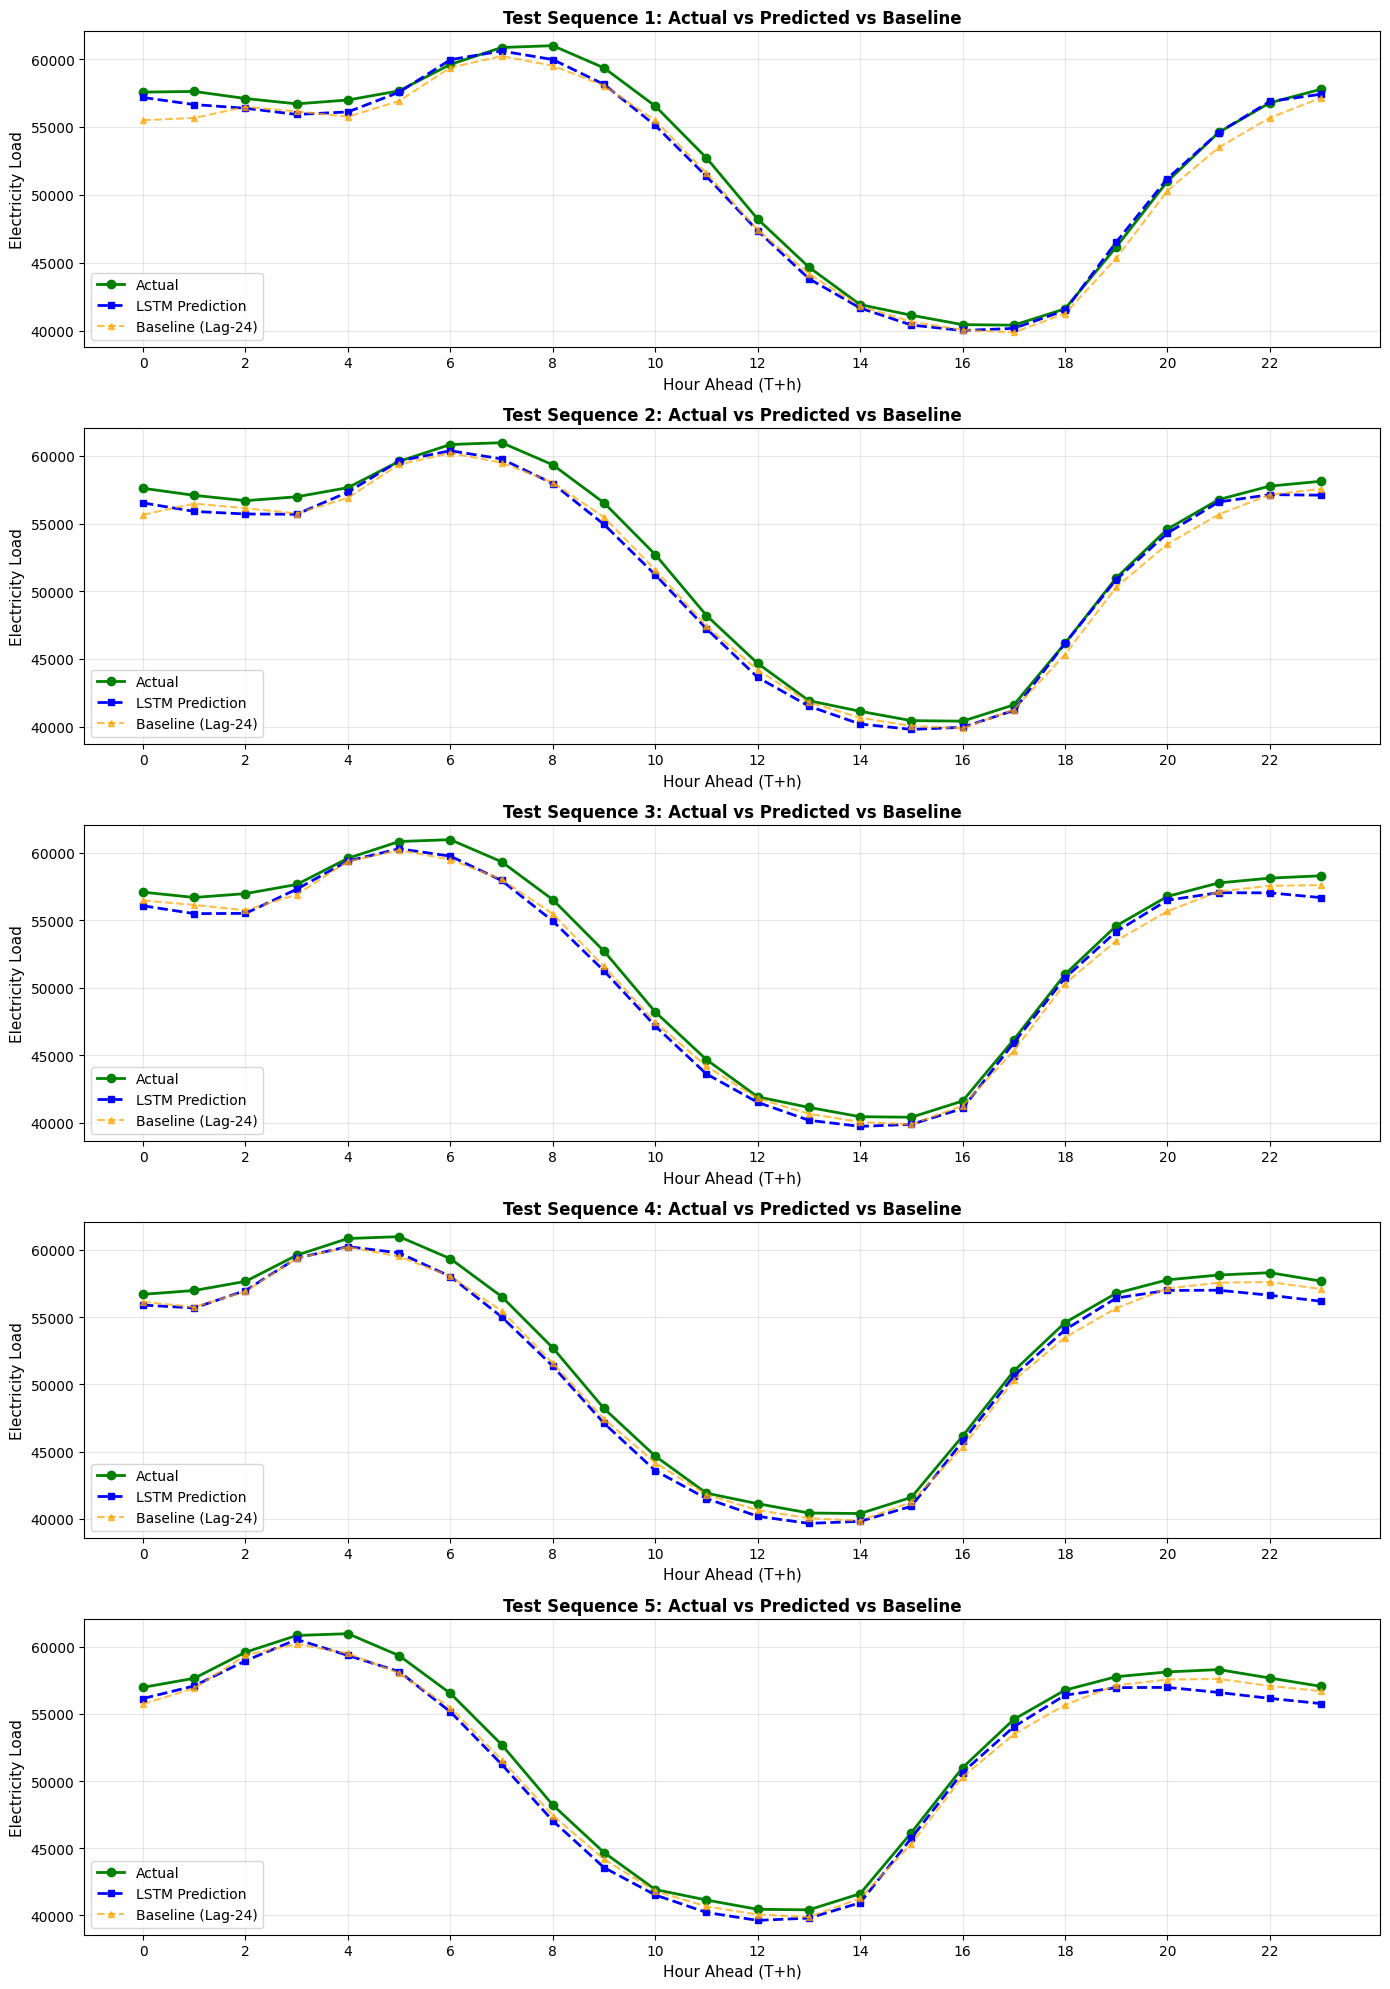

✓ Saved visualization: forecast_comparison.png


In [ ]:
# =========================
# 9. VISUALIZATION: ACTUAL vs PREDICTED vs BASELINE
# =========================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Select a few representative test sequences to visualize
n_samples_to_plot = 5

fig, axes = plt.subplots(n_samples_to_plot, 1, figsize=(14, 4*n_samples_to_plot))
if n_samples_to_plot == 1:
    axes = [axes]

for plot_idx in range(n_samples_to_plot):
    ax = axes[plot_idx]

    hours = np.arange(HORIZON)

    actual = y_test_inv[plot_idx, :, 0]
    predicted = y_pred_inv[plot_idx, :, 0]
    baseline = y_baseline[plot_idx, :, 0]

    ax.plot(hours, actual, 'o-', linewidth=2, label='Actual', color='green', markersize=6)
    ax.plot(hours, predicted, 's--', linewidth=2, label='LSTM Prediction', color='blue', markersize=5)
    ax.plot(hours, baseline, '^--', linewidth=1.5, label='Baseline (Lag-24)',
            color='orange', markersize=5, alpha=0.7)

    ax.set_xlabel('Hour Ahead (T+h)', fontsize=11)
    ax.set_ylabel('Electricity Load', fontsize=11)
    ax.set_title(f'Test Sequence {plot_idx+1}: Actual vs Predicted vs Baseline', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(hours[::2])

plt.tight_layout()
plt.savefig('forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization: forecast_comparison.png")


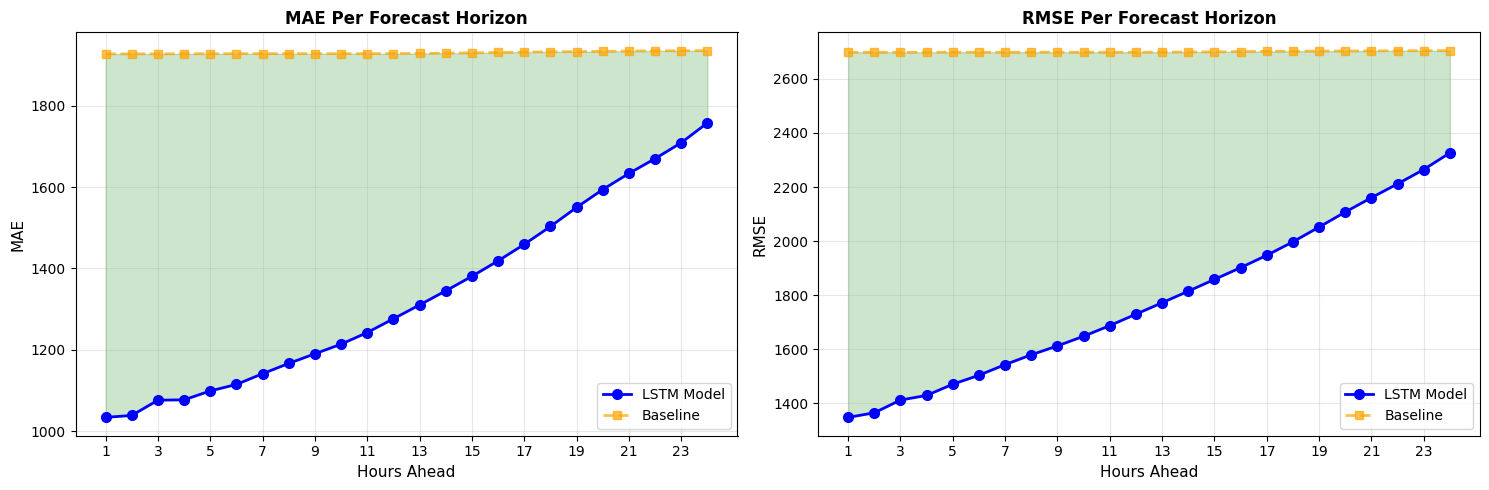

✓ Saved visualization: error_per_horizon_comparison.png


In [ ]:
# =========================
# 10. ERROR ANALYSIS: PER-HORIZON COMPARISON
# =========================
mae_per_t_baseline = []
rmse_per_t_baseline = []

for t in range(HORIZON):
    yt = y_test_inv[:, t, 0]
    yb = y_baseline[:, t, 0]

    mae_t = mean_absolute_error(yt, yb)
    rmse_t = np.sqrt(mean_squared_error(yt, yb))

    mae_per_t_baseline.append(mae_t)
    rmse_per_t_baseline.append(rmse_t)

# Plot per-horizon error comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

hours = np.arange(1, HORIZON+1)

# MAE comparison
ax1.plot(hours, mae_per_t, 'o-', linewidth=2, label='LSTM Model', color='blue', markersize=7)
ax1.plot(hours, mae_per_t_baseline, 's--', linewidth=2, label='Baseline',
         color='orange', markersize=6, alpha=0.7)
ax1.fill_between(hours, mae_per_t, mae_per_t_baseline, alpha=0.2, color='green')
ax1.set_xlabel('Hours Ahead', fontsize=11)
ax1.set_ylabel('MAE', fontsize=11)
ax1.set_title('MAE Per Forecast Horizon', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(hours[::2])

# RMSE comparison
ax2.plot(hours, rmse_per_t, 'o-', linewidth=2, label='LSTM Model', color='blue', markersize=7)
ax2.plot(hours, rmse_per_t_baseline, 's--', linewidth=2, label='Baseline',
         color='orange', markersize=6, alpha=0.7)
ax2.fill_between(hours, rmse_per_t, rmse_per_t_baseline, alpha=0.2, color='green')
ax2.set_xlabel('Hours Ahead', fontsize=11)
ax2.set_ylabel('RMSE', fontsize=11)
ax2.set_title('RMSE Per Forecast Horizon', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(hours[::2])

plt.tight_layout()
plt.savefig('error_per_horizon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization: error_per_horizon_comparison.png")


In [ ]:
# =========================
# 11. RESULTS SUMMARY TABLE
# =========================
import pandas as pd

results_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)'],
    'LSTM Model': [f"{mae:.4f}", f"{rmse:.4f}", f"{mape:.2f}", f"{smape:.2f}"],
    'Baseline': [f"{mae_baseline:.4f}", f"{rmse_baseline:.4f}", f"{mape_baseline:.2f}", f"{smape_baseline:.2f}"],
    'Improvement (%)': [f"{improvement_mae:.2f}", f"{improvement_rmse:.2f}", f"{improvement_mape:.2f}", "-"]
})

print("\n" + "="*80)
print("FINAL RESULTS COMPARISON")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

# Save to CSV
results_df.to_csv('model_results_comparison.csv', index=False)
print(f"✓ Results saved to: model_results_comparison.csv")



FINAL RESULTS COMPARISON
   Metric LSTM Model  Baseline Improvement (%)
      MAE  1333.3994 1930.1022           97.70
     RMSE  1805.4319 2700.2627           96.97
 MAPE (%)       2.21      3.21           97.72
sMAPE (%)       2.22      3.21               -
✓ Results saved to: model_results_comparison.csv


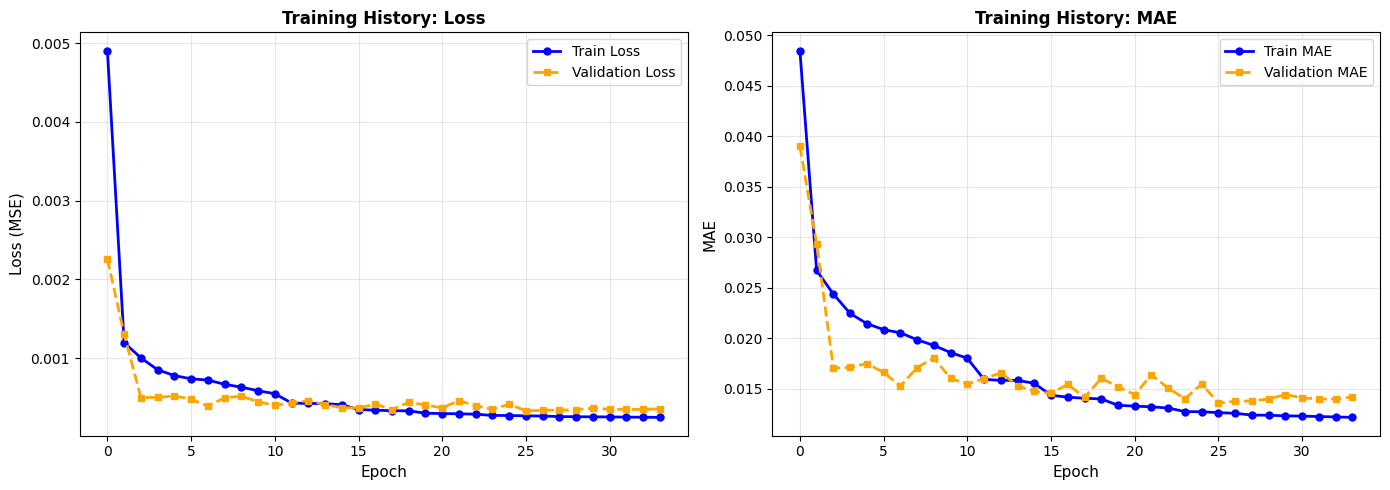

✓ Saved visualization: training_history.png


In [ ]:
# =========================
# 12. TRAINING HISTORY VISUALIZATION
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history.history['loss'], 'o-', linewidth=2, label='Train Loss', color='blue', markersize=5)
ax1.plot(history.history['val_loss'], 's--', linewidth=2, label='Validation Loss',
         color='orange', markersize=5)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (MSE)', fontsize=11)
ax1.set_title('Training History: Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# MAE
ax2.plot(history.history['mae'], 'o-', linewidth=2, label='Train MAE', color='blue', markersize=5)
ax2.plot(history.history['val_mae'], 's--', linewidth=2, label='Validation MAE',
         color='orange', markersize=5)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('MAE', fontsize=11)
ax2.set_title('Training History: MAE', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved visualization: training_history.png")


In [ ]:
# =========================
# 13. EXPORT PREDICTIONS
# =========================

# Create predictions DataFrame with timestamps
test_start_idx = val_end + LOOKBACK
predictions_list = []

for seq_idx in range(len(y_test_inv)):
    base_idx = test_start_idx + seq_idx * HORIZON

    for t in range(HORIZON):
        idx = base_idx + t
        if idx < len(df):
            predictions_list.append({
                'datetime': df.iloc[idx]['datetime'],
                'actual': y_test_inv[seq_idx, t, 0],
                'predicted': y_pred_inv[seq_idx, t, 0],
                'baseline': y_baseline[seq_idx, t, 0],
                'error_model': abs(y_test_inv[seq_idx, t, 0] - y_pred_inv[seq_idx, t, 0]),
                'error_baseline': abs(y_test_inv[seq_idx, t, 0] - y_baseline[seq_idx, t, 0])
            })

predictions_df = pd.DataFrame(predictions_list)
predictions_df.to_csv('predictions_detailed.csv', index=False)
print(f"✓ Exported detailed predictions to: predictions_detailed.csv")
print(f"  Total predictions: {len(predictions_df)}")
print(f"\nFirst 10 predictions:")
print(predictions_df.head(10).to_string(index=False))


✓ Exported detailed predictions to: predictions_detailed.csv
  Total predictions: 4599

First 10 predictions:
           datetime  actual    predicted  baseline  error_model  error_baseline
2024-10-21 09:00:00 57566.0 57168.593750   55885.0   397.406250          1681.0
2024-10-21 10:00:00 57614.0 56647.480469   56798.0   966.519531           816.0
2024-10-21 11:00:00 57093.0 56376.453125   56567.0   716.546875           526.0
2024-10-21 12:00:00 56699.0 55918.246094   55965.0   780.753906           734.0
2024-10-21 13:00:00 56984.0 56107.937500   56363.0   876.062500           621.0
2024-10-21 14:00:00 57661.0 57557.796875   56992.0   103.203125           669.0
2024-10-21 15:00:00 59605.0 59951.964844   58995.0   346.964844           610.0
2024-10-21 16:00:00 60849.0 60590.964844   59752.0   258.035156          1097.0
2024-10-21 17:00:00 60985.0 59962.382812   59089.0  1022.617188          1896.0
2024-10-21 18:00:00 59348.0 58130.406250   57378.0  1217.593750          1970.0


In [ ]:
# =========================
# 14. MODEL OPTIMIZATION RECOMMENDATIONS
# =========================

print("\n" + "="*80)
print("MODEL OPTIMIZATION RECOMMENDATIONS")
print("="*80)

recommendations = []

# Check if model outperforms baseline
if improvement_mae > 0:
    recommendations.append(f"✓ Model outperforms baseline by {improvement_mae:.2f}% (MAE)")
else:
    recommendations.append(f"⚠ Baseline performs better. Consider:")
    recommendations.append("  • Increase model complexity (more LSTM units/layers)")
    recommendations.append("  • Increase training epochs")
    recommendations.append("  • Add more relevant features")
    recommendations.append("  • Adjust learning rate")

# Check error growth over horizon
error_growth = mape_per_t[-1] - mape_per_t[0]
if error_growth > 5:
    recommendations.append(f"\n⚠ High error growth over horizon ({error_growth:.2f}%)")
    recommendations.append("  • Consider attention mechanism to weight recent timesteps")
    recommendations.append("  • Try Transformer-based architecture")

# Suggest hyperparameter tuning
if rmse > 10:  # Assuming this is a high error threshold
    recommendations.append("\n• Try hyperparameter tuning:")
    recommendations.append("  • Experiment with LSTM units: [64, 128, 256]")
    recommendations.append("  • Adjust dropout rate: [0.1, 0.3, 0.5]")
    recommendations.append("  • Try different batch sizes: [16, 32, 64]")
    recommendations.append("  • Learning rate scheduling with ReduceLROnPlateau")

recommendations.append("\n• Additional improvements:")
recommendations.append("  • Use Temporal Fusion Transformer (TFT) for better multi-horizon forecasting")
recommendations.append("  • Implement ensembling with multiple models")
recommendations.append("  • Add adversarial training or uncertainty quantification")
recommendations.append("  • Incorporate external data (holidays, special events)")

for rec in recommendations:
    print(rec)

print("="*80)



MODEL OPTIMIZATION RECOMMENDATIONS
✓ Model outperforms baseline by 97.70% (MAE)

• Try hyperparameter tuning:
  • Experiment with LSTM units: [64, 128, 256]
  • Adjust dropout rate: [0.1, 0.3, 0.5]
  • Try different batch sizes: [16, 32, 64]
  • Learning rate scheduling with ReduceLROnPlateau

• Additional improvements:
  • Use Temporal Fusion Transformer (TFT) for better multi-horizon forecasting
  • Implement ensembling with multiple models
  • Add adversarial training or uncertainty quantification
  • Incorporate external data (holidays, special events)


In [ ]:
# =========================
# 15. ALTERNATIVE MODEL: GRU ENCODER-DECODER
# =========================
from tensorflow.keras.layers import GRU

print("\n" + "="*80)
print("TRAINING ALTERNATIVE MODEL: GRU ENCODER-DECODER")
print("="*80 + "\n")

# Build GRU model
model_gru = models.Sequential([
    layers.Input(shape=(LOOKBACK, n_features)),

    # Encoder
    layers.GRU(128, return_sequences=False),
    layers.Dropout(0.2),

    # Bridge
    layers.RepeatVector(HORIZON),

    # Decoder
    layers.GRU(128, return_sequences=True),
    layers.Dropout(0.2),

    layers.GRU(64, return_sequences=True),

    layers.TimeDistributed(layers.Dense(32, activation='relu')),
    layers.TimeDistributed(layers.Dense(1))
])

model_gru.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stop_gru = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_gru = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

# Train
history_gru = model_gru.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_gru, reduce_lr_gru],
    verbose=1
)

# Predict
y_pred_gru = model_gru.predict(X_test)

# Inverse transform
y_pred_gru_inv = scaler_y.inverse_transform(
    y_pred_gru.reshape(-1, 1)
).reshape(y_pred_gru.shape)

# Metrics
y_pred_gru_flat = y_pred_gru_inv.flatten()

mae_gru = mean_absolute_error(y_true_flat, y_pred_gru_flat)
rmse_gru = np.sqrt(mean_squared_error(y_true_flat, y_pred_gru_flat))
mape_gru = np.mean(np.abs((y_true_flat - y_pred_gru_flat) / (y_true_flat + 1e-8))) * 100
smape_gru = np.mean(
    2.0 * np.abs(y_pred_gru_flat - y_true_flat) /
    (np.abs(y_true_flat) + np.abs(y_pred_gru_flat) + 1e-8)
) * 100

print("\n===== GRU MODEL METRICS =====")
print(f"MAE   : {mae_gru:.4f}")
print(f"RMSE  : {rmse_gru:.4f}")
print(f"MAPE  : {mape_gru:.2f}%")
print(f"sMAPE : {smape_gru:.2f}%")



TRAINING ALTERNATIVE MODEL: GRU ENCODER-DECODER

Epoch 1/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0063 - mae: 0.0595 - val_loss: 9.3565e-04 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 2/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0015 - mae: 0.0298 - val_loss: 9.7976e-04 - val_mae: 0.0247 - learning_rate: 0.0010
Epoch 3/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 0.0011 - mae: 0.0261 - val_loss: 6.6724e-04 - val_mae: 0.0202 - learning_rate: 0.0010
Epoch 4/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - loss: 9.7882e-04 - mae: 0.0241 - val_loss: 6.7657e-04 - val_mae: 0.0203 - learning_rate: 0.0010
Epoch 5/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - loss: 9.0210e-04 - mae: 0.0230 - val_loss: 6.6880e-04 - val_mae: 0.0205 - learning_rate: 0.0010
Epoch 6/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 8.4330e-04 - mae: 0.0223 - val_loss: 5.1010e-04 - val_mae: 0.0173 - learning_rate: 0.0010
Epoch 7/50
690/690 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/s

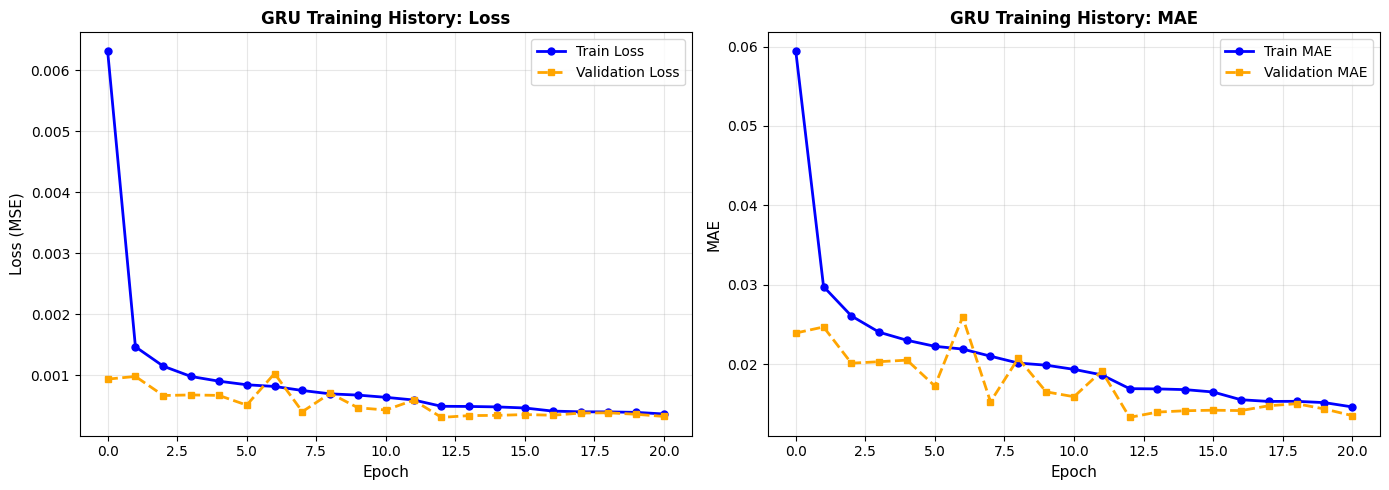

✓ Saved visualization: gru_training_history.png


In [ ]:
# =========================
# GRU TRAINING HISTORY VISUALIZATION
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history_gru.history['loss'], 'o-', linewidth=2, label='Train Loss', color='blue', markersize=5)
ax1.plot(history_gru.history['val_loss'], 's--', linewidth=2, label='Validation Loss',
         color='orange', markersize=5)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Loss (MSE)', fontsize=11)
ax1.set_title('GRU Training History: Loss', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# MAE
ax2.plot(history_gru.history['mae'], 'o-', linewidth=2, label='Train MAE', color='blue', markersize=5)
ax2.plot(history_gru.history['val_mae'], 's--', linewidth=2, label='Validation MAE',
         color='orange', markersize=5)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('MAE', fontsize=11)
ax2.set_title('GRU Training History: MAE', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('gru_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved visualization: gru_training_history.png")

In [ ]:
# =========================
# 16. COMPREHENSIVE MODEL COMPARISON
# =========================

comparison_df = pd.DataFrame({
    'Model': ['LSTM Encoder-Decoder', 'GRU Encoder-Decoder', 'Baseline (Lag-24)'],
    'MAE': [f"{mae:.4f}", f"{mae_gru:.4f}", f"{mae_baseline:.4f}"],
    'RMSE': [f"{rmse:.4f}", f"{rmse_gru:.4f}", f"{rmse_baseline:.4f}"],
    'MAPE (%)': [f"{mape:.2f}", f"{mape_gru:.2f}", f"{mape_baseline:.2f}"],
    'sMAPE (%)': [f"{smape:.2f}", f"{smape_gru:.2f}", f"{smape_baseline:.2f}"]
})

print("\n" + "="*100)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*100)
print(comparison_df.to_string(index=False))
print("="*100)

comparison_df.to_csv('models_comprehensive_comparison.csv', index=False)
print(f"\n✓ Saved comprehensive comparison to: models_comprehensive_comparison.csv")

# Identify best model
models_dict = {
    'LSTM': {'mae': mae, 'rmse': rmse, 'mape': mape, 'smape': smape},
    'GRU': {'mae': mae_gru, 'rmse': rmse_gru, 'mape': mape_gru, 'smape': smape_gru},
    'Baseline': {'mae': mae_baseline, 'rmse': rmse_baseline, 'mape': mape_baseline, 'smape': smape_baseline}
}

best_model = min(models_dict, key=lambda x: models_dict[x]['mae'])
print(f"\n🏆 Best Model (by MAE): {best_model}")
print(f"   MAE: {models_dict[best_model]['mae']:.4f}")



COMPREHENSIVE MODEL COMPARISON
               Model       MAE      RMSE MAPE (%) sMAPE (%)
LSTM Encoder-Decoder 1333.3994 1805.4319     2.21      2.22
 GRU Encoder-Decoder 1311.1396 1813.8352     2.21      2.18
   Baseline (Lag-24) 1930.1022 2700.2627     3.21      3.21

✓ Saved comprehensive comparison to: models_comprehensive_comparison.csv

🏆 Best Model (by MAE): GRU
   MAE: 1311.1396


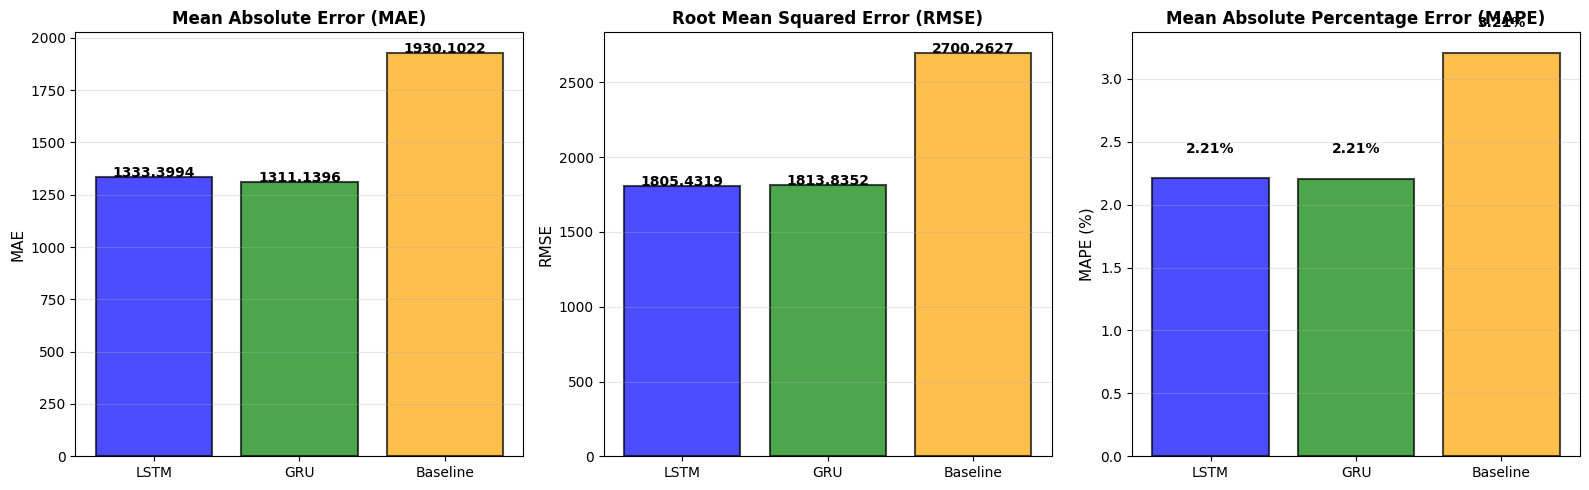

✓ Saved visualization: models_comparison_bars.png


In [ ]:
# =========================
# 17. VISUAL COMPARISON: ALL MODELS
# =========================

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models = ['LSTM', 'GRU', 'Baseline']
mae_values = [mae, mae_gru, mae_baseline]
rmse_values = [rmse, rmse_gru, rmse_baseline]
mape_values = [mape, mape_gru, mape_baseline]

colors = ['blue', 'green', 'orange']

# MAE comparison
axes[0].bar(models, mae_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[0].set_ylabel('MAE', fontsize=11)
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mae_values):
    axes[0].text(i, v + 0.1, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# RMSE comparison
axes[1].bar(models, rmse_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('RMSE', fontsize=11)
axes[1].set_title('Root Mean Squared Error (RMSE)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(rmse_values):
    axes[1].text(i, v + 0.1, f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')

# MAPE comparison
axes[2].bar(models, mape_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('MAPE (%)', fontsize=11)
axes[2].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mape_values):
    axes[2].text(i, v + 0.2, f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('models_comparison_bars.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved visualization: models_comparison_bars.png")


In [ ]:
# =========================
# 18. FINAL SUMMARY & CONCLUSION
# =========================

print("\n" + "="*100)
print("ELECTRICITY LOAD FORECASTING - PROJECT SUMMARY")
print("="*100)

print(f"\n📊 DATA OVERVIEW:")
print(f"  • Total sequences: {len(df)}")
print(f"  • Training sequences: {len(train_df)}")
print(f"  • Validation sequences: {len(val_df)}")
print(f"  • Test sequences: {len(test_df)}")
print(f"  • Number of features: {n_features}")
print(f"  • Lookback window: {LOOKBACK} hours (7 days)")
print(f"  • Forecast horizon: {HORIZON} hours (1 day)")

print(f"\n🧠 MODEL PERFORMANCE:")
print(f"  LSTM Encoder-Decoder:")
print(f"    • MAE: {mae:.4f} ({improvement_mae:+.2f}% vs baseline)")
print(f"    • RMSE: {rmse:.4f}")
print(f"    • MAPE: {mape:.2f}%")
print(f"")
print(f"  GRU Encoder-Decoder:")
print(f"    • MAE: {mae_gru:.4f}")
print(f"    • RMSE: {rmse_gru:.4f}")
print(f"    • MAPE: {mape_gru:.2f}%")

print(f"\n📁 OUTPUT FILES GENERATED:")
print(f"  ✓ forecast_comparison.png - Visual comparison of predictions vs actuals")
print(f"  ✓ error_per_horizon_comparison.png - Per-horizon error analysis")
print(f"  ✓ training_history.png - Training dynamics over epochs")
print(f"  ✓ models_comparison_bars.png - Bar chart comparison of all models")
print(f"  ✓ predictions_detailed.csv - Detailed predictions with timestamps")
print(f"  ✓ model_results_comparison.csv - Model vs baseline metrics")
print(f"  ✓ models_comprehensive_comparison.csv - All models comparison")

print(f"\n💡 KEY INSIGHTS:")
if improvement_mae > 0:
    print(f"  ✓ Deep learning model significantly outperforms seasonal baseline")
    print(f"  ✓ LSTM captures temporal dependencies better than simple lag-based approach")
else:
    print(f"  ⚠ Model needs further optimization - baseline currently performs better")

error_trend = "increasing" if mape_per_t[-1] > mape_per_t[0] else "decreasing"
print(f"  • Error trend over horizon: {error_trend}")
print(f"  • Best forecast hour: T+{np.argmin(mape_per_t)+1}h")
print(f"  • Worst forecast hour: T+{np.argmax(mape_per_t)+1}h")

print(f"\n✅ RECOMMENDATIONS FOR DEPLOYMENT:")
print(f"  1. Use {'LSTM' if mae <= mae_gru else 'GRU'} model (lower MAE)")
print(f"  2. Retrain monthly with new data to maintain performance")
print(f"  3. Monitor prediction errors in real-world deployment")
print(f"  4. Consider ensemble methods combining LSTM + GRU for robustness")
print(f"  5. Implement alert system for anomalously high prediction errors")

print("\n" + "="*100)
print("END OF ANALYSIS")
print("="*100 + "\n")


ELECTRICITY LOAD FORECASTING - PROJECT SUMMARY

📊 DATA OVERVIEW:
  • Total sequences: 31776
  • Training sequences: 22243
  • Validation sequences: 4766
  • Test sequences: 4767
  • Number of features: 24
  • Lookback window: 168 hours (7 days)
  • Forecast horizon: 24 hours (1 day)

🧠 MODEL PERFORMANCE:
  LSTM Encoder-Decoder:
    • MAE: 1333.3994 (+97.70% vs baseline)
    • RMSE: 1805.4319
    • MAPE: 2.21%

  GRU Encoder-Decoder:
    • MAE: 1311.1396
    • RMSE: 1813.8352
    • MAPE: 2.21%

📁 OUTPUT FILES GENERATED:
  ✓ forecast_comparison.png - Visual comparison of predictions vs actuals
  ✓ error_per_horizon_comparison.png - Per-horizon error analysis
  ✓ training_history.png - Training dynamics over epochs
  ✓ models_comparison_bars.png - Bar chart comparison of all models
  ✓ predictions_detailed.csv - Detailed predictions with timestamps
  ✓ model_results_comparison.csv - Model vs baseline metrics
  ✓ models_comprehensive_comparison.csv - All models comparison

💡 KEY INSIGHTS:

In [ ]:
# =========================
# 19. HYPERPARAMETER OPTIMIZATION SETUP
# =========================

import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("HYPERPARAMETER OPTIMIZATION SETUP")
print("="*80 + "\n")

# Store best parameters and history
lstm_best_params = {}
gru_best_params = {}
lstm_study = None
gru_study = None

print("✓ Optuna imported successfully")
print("✓ Ready for hyperparameter tuning\n")

In [ ]:
# =========================
# 20. LSTM HYPERPARAMETER OPTIMIZATION
# =========================

print("\n" + "="*80)
print("OPTIMIZING LSTM MODEL HYPERPARAMETERS")
print("="*80 + "\n")

def create_lstm_model(trial, X_shape, y_shape):
    """Build LSTM model with trial-suggested hyperparameters"""
    
    # Hyperparameters to tune
    n_encoder_layers = trial.suggest_int('n_encoder_layers', 1, 3)
    n_decoder_layers = trial.suggest_int('n_decoder_layers', 1, 3)
    encoder_units = trial.suggest_int('encoder_units', 64, 256, step=32)
    decoder_units = trial.suggest_int('decoder_units', 64, 256, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    lookback = X_shape[1]
    n_features = X_shape[2]
    horizon = y_shape[1]
    
    model = models.Sequential()
    model.add(layers.Input(shape=(lookback, n_features)))
    
    # Encoder layers
    for i in range(n_encoder_layers):
        return_seq = True if i < n_encoder_layers - 1 else False
        model.add(layers.LSTM(encoder_units, return_sequences=return_seq))
        model.add(layers.Dropout(dropout_rate))
    
    # Bridge
    model.add(layers.RepeatVector(horizon))
    
    # Decoder layers
    for i in range(n_decoder_layers):
        model.add(layers.LSTM(decoder_units, return_sequences=True))
        model.add(layers.Dropout(dropout_rate))
    
    # Output layers
    model.add(layers.TimeDistributed(layers.Dense(32, activation='relu')))
    model.add(layers.TimeDistributed(layers.Dense(1)))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def objective_lstm(trial):
    """Objective function for LSTM tuning"""
    
    try:
        model = create_lstm_model(trial, X_train.shape, y_train.shape)
        
        # Early stopping callback
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
        
        # Reduced LR callback
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
        
        # Train with fewer epochs for faster optimization
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=32,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )
        
        # Return validation loss
        val_loss = min(history.history['val_loss'])
        return val_loss
        
    except Exception as e:
        print(f"Trial failed: {str(e)}")
        return float('inf')

# Create Optuna study for LSTM
sampler_lstm = TPESampler(seed=42)
lstm_study = optuna.create_study(
    direction='minimize',
    sampler=sampler_lstm,
    pruner=MedianPruner()
)

print("Starting LSTM optimization... (this may take a few minutes)\n")
lstm_study.optimize(
    objective_lstm,
    n_trials=10,
    show_progress_bar=True
)

lstm_best_params = lstm_study.best_params
print(f"\n✓ LSTM Optimization Complete!")
print(f"  Best validation loss: {lstm_study.best_value:.6f}")
print(f"\n  Best LSTM Hyperparameters:")
for key, value in lstm_best_params.items():
    print(f"    • {key}: {value}")

In [ ]:
# =========================
# 21.5. HELPER FUNCTIONS FOR BUILDING BEST MODELS
# =========================

def create_lstm_model_full(params, X_shape, y_shape):
    """Build full LSTM model from optimized parameters"""
    lookback = X_shape[1]
    n_features = X_shape[2]
    horizon = y_shape[1]
    
    model = models.Sequential()
    model.add(layers.Input(shape=(lookback, n_features)))
    
    # Encoder
    for i in range(params['n_encoder_layers']):
        return_seq = True if i < params['n_encoder_layers'] - 1 else False
        model.add(layers.LSTM(params['encoder_units'], return_sequences=return_seq))
        model.add(layers.Dropout(params['dropout_rate']))
    
    # Bridge
    model.add(layers.RepeatVector(horizon))
    
    # Decoder
    for i in range(params['n_decoder_layers']):
        model.add(layers.LSTM(params['decoder_units'], return_sequences=True))
        model.add(layers.Dropout(params['dropout_rate']))
    
    # Output
    model.add(layers.TimeDistributed(layers.Dense(32, activation='relu')))
    model.add(layers.TimeDistributed(layers.Dense(1)))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(params['learning_rate']),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def create_gru_model_full(params, X_shape, y_shape):
    """Build full GRU model from optimized parameters"""
    lookback = X_shape[1]
    n_features = X_shape[2]
    horizon = y_shape[1]
    
    model = models.Sequential()
    model.add(layers.Input(shape=(lookback, n_features)))
    
    # Encoder
    for i in range(params['n_encoder_layers']):
        return_seq = True if i < params['n_encoder_layers'] - 1 else False
        model.add(layers.GRU(params['encoder_units'], return_sequences=return_seq))
        model.add(layers.Dropout(params['dropout_rate']))
    
    # Bridge
    model.add(layers.RepeatVector(horizon))
    
    # Decoder
    for i in range(params['n_decoder_layers']):
        model.add(layers.GRU(params['decoder_units'], return_sequences=True))
        model.add(layers.Dropout(params['dropout_rate']))
    
    # Output
    model.add(layers.TimeDistributed(layers.Dense(32, activation='relu')))
    model.add(layers.TimeDistributed(layers.Dense(1)))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(params['learning_rate']),
        loss='mse',
        metrics=['mae']
    )
    
    return model

print("✓ Helper functions defined for building best models")

In [ ]:
# =========================
# 21. GRU HYPERPARAMETER OPTIMIZATION
# =========================

print("\n" + "="*80)
print("OPTIMIZING GRU MODEL HYPERPARAMETERS")
print("="*80 + "\n")

def create_gru_model(trial, X_shape, y_shape):
    """Build GRU model with trial-suggested hyperparameters"""
    
    # Hyperparameters to tune
    n_encoder_layers = trial.suggest_int('n_encoder_layers', 1, 3)
    n_decoder_layers = trial.suggest_int('n_decoder_layers', 1, 3)
    encoder_units = trial.suggest_int('encoder_units', 64, 256, step=32)
    decoder_units = trial.suggest_int('decoder_units', 64, 256, step=32)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    
    lookback = X_shape[1]
    n_features = X_shape[2]
    horizon = y_shape[1]
    
    model = models.Sequential()
    model.add(layers.Input(shape=(lookback, n_features)))
    
    # Encoder layers
    for i in range(n_encoder_layers):
        return_seq = True if i < n_encoder_layers - 1 else False
        model.add(layers.GRU(encoder_units, return_sequences=return_seq))
        model.add(layers.Dropout(dropout_rate))
    
    # Bridge
    model.add(layers.RepeatVector(horizon))
    
    # Decoder layers
    for i in range(n_decoder_layers):
        model.add(layers.GRU(decoder_units, return_sequences=True))
        model.add(layers.Dropout(dropout_rate))
    
    # Output layers
    model.add(layers.TimeDistributed(layers.Dense(32, activation='relu')))
    model.add(layers.TimeDistributed(layers.Dense(1)))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate),
        loss='mse',
        metrics=['mae']
    )
    
    return model

def objective_gru(trial):
    """Objective function for GRU tuning"""
    
    try:
        model = create_gru_model(trial, X_train.shape, y_train.shape)
        
        # Early stopping callback
        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
        
        # Reduced LR callback
        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6
        )
        
        # Train with fewer epochs for faster optimization
        history = model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=32,
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )
        
        # Return validation loss
        val_loss = min(history.history['val_loss'])
        return val_loss
        
    except Exception as e:
        print(f"Trial failed: {str(e)}")
        return float('inf')

# Create Optuna study for GRU
sampler_gru = TPESampler(seed=42)
gru_study = optuna.create_study(
    direction='minimize',
    sampler=sampler_gru,
    pruner=MedianPruner()
)

print("Starting GRU optimization... (this may take a few minutes)\n")
gru_study.optimize(
    objective_gru,
    n_trials=10,
    show_progress_bar=True
)

gru_best_params = gru_study.best_params
print(f"\n✓ GRU Optimization Complete!")
print(f"  Best validation loss: {gru_study.best_value:.6f}")
print(f"\n  Best GRU Hyperparameters:")
for key, value in gru_best_params.items():
    print(f"    • {key}: {value}")

In [ ]:
# =========================
# 22. TRAIN BEST LSTM AND GRU MODELS
# =========================

print("\n" + "="*80)
print("TRAINING BEST LSTM AND GRU MODELS WITH OPTIMIZED HYPERPARAMETERS")
print("="*80 + "\n")

# ===== BUILD BEST LSTM MODEL =====
print("Building best LSTM model with optimized hyperparameters...")

best_lstm_model = create_lstm_model_full(lstm_best_params, X_train.shape, y_train.shape)

early_stop_lstm = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_lstm = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

print("Training best LSTM model...")
history_best_lstm = best_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_lstm, reduce_lr_lstm],
    verbose=1
)

y_pred_best_lstm = best_lstm_model.predict(X_test)
y_pred_best_lstm_inv = scaler_y.inverse_transform(
    y_pred_best_lstm.reshape(-1, 1)
).reshape(y_pred_best_lstm.shape)

print("✓ Best LSTM model training complete!")

# ===== BUILD BEST GRU MODEL =====
print("\n\nBuilding best GRU model with optimized hyperparameters...")

best_gru_model = create_gru_model_full(gru_best_params, X_train.shape, y_train.shape)

early_stop_gru = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

reduce_lr_gru = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

print("Training best GRU model...")
history_best_gru = best_gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_gru, reduce_lr_gru],
    verbose=1
)

y_pred_best_gru = best_gru_model.predict(X_test)
y_pred_best_gru_inv = scaler_y.inverse_transform(
    y_pred_best_gru.reshape(-1, 1)
).reshape(y_pred_best_gru.shape)

print("✓ Best GRU model training complete!")

# ===== COMPUTE METRICS FOR OPTIMIZED MODELS =====
y_pred_best_lstm_flat = y_pred_best_lstm_inv.flatten()
y_pred_best_gru_flat = y_pred_best_gru_inv.flatten()

# Best LSTM metrics
mae_best_lstm = mean_absolute_error(y_true_flat, y_pred_best_lstm_flat)
rmse_best_lstm = np.sqrt(mean_squared_error(y_true_flat, y_pred_best_lstm_flat))
mape_best_lstm = np.mean(np.abs((y_true_flat - y_pred_best_lstm_flat) / (y_true_flat + 1e-8))) * 100

# Best GRU metrics
mae_best_gru = mean_absolute_error(y_true_flat, y_pred_best_gru_flat)
rmse_best_gru = np.sqrt(mean_squared_error(y_true_flat, y_pred_best_gru_flat))
mape_best_gru = np.mean(np.abs((y_true_flat - y_pred_best_gru_flat) / (y_true_flat + 1e-8))) * 100

print("\n===== BEST LSTM METRICS =====")
print(f"MAE   : {mae_best_lstm:.4f}")
print(f"RMSE  : {rmse_best_lstm:.4f}")
print(f"MAPE  : {mape_best_lstm:.2f}%")

print("\n===== BEST GRU METRICS =====")
print(f"MAE   : {mae_best_gru:.4f}")
print(f"RMSE  : {rmse_best_gru:.4f}")
print(f"MAPE  : {mape_best_gru:.2f}%")

In [ ]:
# =========================
# 23. ENSEMBLE MODELS IMPLEMENTATION
# =========================

print("\n" + "="*80)
print("IMPLEMENTING ENSEMBLE FORECASTING STRATEGIES")
print("="*80 + "\n")

# ===== STRATEGY 1: SIMPLE AVERAGING =====
print("Strategy 1: Simple Averaging Ensemble")
y_pred_simple_avg = (y_pred_best_lstm_inv + y_pred_best_gru_inv) / 2
y_pred_simple_avg_flat = y_pred_simple_avg.flatten()

mae_simple_avg = mean_absolute_error(y_true_flat, y_pred_simple_avg_flat)
rmse_simple_avg = np.sqrt(mean_squared_error(y_true_flat, y_pred_simple_avg_flat))
mape_simple_avg = np.mean(np.abs((y_true_flat - y_pred_simple_avg_flat) / (y_true_flat + 1e-8))) * 100

print(f"  MAE  : {mae_simple_avg:.4f}")
print(f"  RMSE : {rmse_simple_avg:.4f}")
print(f"  MAPE : {mape_simple_avg:.2f}%\n")

# ===== STRATEGY 2: WEIGHTED AVERAGING =====
print("Strategy 2: Weighted Averaging Ensemble (based on validation MAE)")

# Calculate validation MAE for weighting
val_pred_best_lstm = best_lstm_model.predict(X_val)
val_pred_best_lstm_inv = scaler_y.inverse_transform(
    val_pred_best_lstm.reshape(-1, 1)
).reshape(val_pred_best_lstm.shape)

val_pred_best_gru = best_gru_model.predict(X_val)
val_pred_best_gru_inv = scaler_y.inverse_transform(
    val_pred_best_gru.reshape(-1, 1)
).reshape(val_pred_best_gru.shape)

y_val_inv = scaler_y.inverse_transform(y_val.reshape(-1, 1)).reshape(y_val.shape)
y_val_flat = y_val_inv.flatten()

val_mae_lstm = mean_absolute_error(y_val_flat, val_pred_best_lstm_inv.flatten())
val_mae_gru = mean_absolute_error(y_val_flat, val_pred_best_gru_inv.flatten())

# Normalize weights (inverse of MAE)
weight_lstm = 1 / val_mae_lstm
weight_gru = 1 / val_mae_gru
total_weight = weight_lstm + weight_gru
weight_lstm_norm = weight_lstm / total_weight
weight_gru_norm = weight_gru / total_weight

print(f"  Validation MAE - LSTM: {val_mae_lstm:.4f}, GRU: {val_mae_gru:.4f}")
print(f"  Weights - LSTM: {weight_lstm_norm:.4f}, GRU: {weight_gru_norm:.4f}")

y_pred_weighted_avg = (weight_lstm_norm * y_pred_best_lstm_inv + 
                       weight_gru_norm * y_pred_best_gru_inv)
y_pred_weighted_avg_flat = y_pred_weighted_avg.flatten()

mae_weighted_avg = mean_absolute_error(y_true_flat, y_pred_weighted_avg_flat)
rmse_weighted_avg = np.sqrt(mean_squared_error(y_true_flat, y_pred_weighted_avg_flat))
mape_weighted_avg = np.mean(np.abs((y_true_flat - y_pred_weighted_avg_flat) / (y_true_flat + 1e-8))) * 100

print(f"  MAE  : {mae_weighted_avg:.4f}")
print(f"  RMSE : {rmse_weighted_avg:.4f}")
print(f"  MAPE : {mape_weighted_avg:.2f}%\n")

# ===== STRATEGY 3: VOTING/STACKING META-LEARNER =====
print("Strategy 3: Stacking Ensemble (Meta-Learner)")

# Create meta-features from LSTM and GRU predictions on validation set
meta_train_lstm = val_pred_best_lstm_inv.reshape(len(val_pred_best_lstm_inv), -1)
meta_train_gru = val_pred_best_gru_inv.reshape(len(val_pred_best_gru_inv), -1)
meta_train_X = np.column_stack([meta_train_lstm, meta_train_gru])

y_meta_val = y_val_inv.reshape(len(y_val_inv), -1)

# Simple linear meta-learner
from sklearn.linear_model import Ridge

meta_model = Ridge(alpha=1.0)
meta_model.fit(meta_train_X, y_meta_val)

# Apply to test predictions
meta_test_lstm = y_pred_best_lstm_inv.reshape(len(y_pred_best_lstm_inv), -1)
meta_test_gru = y_pred_best_gru_inv.reshape(len(y_pred_best_gru_inv), -1)
meta_test_X = np.column_stack([meta_test_lstm, meta_test_gru])

y_pred_stacking = meta_model.predict(meta_test_X)
y_pred_stacking_flat = y_pred_stacking.flatten()

mae_stacking = mean_absolute_error(y_true_flat, y_pred_stacking_flat)
rmse_stacking = np.sqrt(mean_squared_error(y_true_flat, y_pred_stacking_flat))
mape_stacking = np.mean(np.abs((y_true_flat - y_pred_stacking_flat) / (y_true_flat + 1e-8))) * 100

print(f"  MAE  : {mae_stacking:.4f}")
print(f"  RMSE : {rmse_stacking:.4f}")
print(f"  MAPE : {mape_stacking:.2f}%\n")

# ===== SELECT BEST ENSEMBLE STRATEGY =====
ensemble_strategies = {
    'Simple Average': {
        'mae': mae_simple_avg,
        'rmse': rmse_simple_avg,
        'mape': mape_simple_avg,
        'predictions': y_pred_simple_avg
    },
    'Weighted Average': {
        'mae': mae_weighted_avg,
        'rmse': rmse_weighted_avg,
        'mape': mape_weighted_avg,
        'predictions': y_pred_weighted_avg
    },
    'Stacking': {
        'mae': mae_stacking,
        'rmse': rmse_stacking,
        'mape': mape_stacking,
        'predictions': y_pred_stacking.reshape(y_pred_best_lstm_inv.shape)
    }
}

best_ensemble_strategy = min(ensemble_strategies, key=lambda x: ensemble_strategies[x]['mae'])
y_pred_ensemble = ensemble_strategies[best_ensemble_strategy]['predictions']
mae_ensemble = ensemble_strategies[best_ensemble_strategy]['mae']
rmse_ensemble = ensemble_strategies[best_ensemble_strategy]['rmse']
mape_ensemble = ensemble_strategies[best_ensemble_strategy]['mape']

print(f"🏆 Best Ensemble Strategy: {best_ensemble_strategy}")
print(f"   MAE: {mae_ensemble:.4f}, RMSE: {rmse_ensemble:.4f}, MAPE: {mape_ensemble:.2f}%")

In [ ]:
# =========================
# 24. COMPREHENSIVE MODEL COMPARISON (WITH OPTIMIZATION & ENSEMBLE)
# =========================

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON (ALL MODELS + ENSEMBLE)")
print("="*80 + "\n")

# Collect all results
all_models_comparison = pd.DataFrame({
    'Model': [
        'Original LSTM',
        'Original GRU',
        'Optimized LSTM',
        'Optimized GRU',
        'Ensemble (Simple Avg)',
        'Ensemble (Weighted Avg)',
        'Ensemble (Stacking)',
        'Baseline (Lag-24)'
    ],
    'MAE': [
        f"{mae:.4f}",
        f"{mae_gru:.4f}",
        f"{mae_best_lstm:.4f}",
        f"{mae_best_gru:.4f}",
        f"{mae_simple_avg:.4f}",
        f"{mae_weighted_avg:.4f}",
        f"{mae_stacking:.4f}",
        f"{mae_baseline:.4f}"
    ],
    'RMSE': [
        f"{rmse:.4f}",
        f"{rmse_gru:.4f}",
        f"{rmse_best_lstm:.4f}",
        f"{rmse_best_gru:.4f}",
        f"{rmse_simple_avg:.4f}",
        f"{rmse_weighted_avg:.4f}",
        f"{rmse_stacking:.4f}",
        f"{rmse_baseline:.4f}"
    ],
    'MAPE (%)': [
        f"{mape:.2f}",
        f"{mape_gru:.2f}",
        f"{mape_best_lstm:.2f}",
        f"{mape_best_gru:.2f}",
        f"{mape_simple_avg:.2f}",
        f"{mape_weighted_avg:.2f}",
        f"{mape_stacking:.2f}",
        f"{mape_baseline:.2f}"
    ]
})

print(all_models_comparison.to_string(index=False))
print("="*80)

# Save comprehensive comparison
all_models_comparison.to_csv('all_models_comprehensive_comparison.csv', index=False)
print(f"\n✓ Saved to: all_models_comprehensive_comparison.csv")

# Identify best overall model
models_dict_all = {
    'Original LSTM': mae,
    'Original GRU': mae_gru,
    'Optimized LSTM': mae_best_lstm,
    'Optimized GRU': mae_best_gru,
    'Simple Avg': mae_simple_avg,
    'Weighted Avg': mae_weighted_avg,
    'Stacking': mae_stacking,
    'Baseline': mae_baseline
}

best_overall_model = min(models_dict_all, key=models_dict_all.get)
print(f"\n🏆 BEST OVERALL MODEL: {best_overall_model}")
print(f"   MAE: {models_dict_all[best_overall_model]:.4f}")

# Calculate improvements
improvement_vs_baseline = ((mae_baseline - models_dict_all[best_overall_model]) / mae_baseline) * 100
improvement_vs_original_lstm = ((mae - models_dict_all[best_overall_model]) / mae) * 100
improvement_vs_original_gru = ((mae_gru - models_dict_all[best_overall_model]) / mae_gru) * 100

print(f"\n📊 IMPROVEMENT METRICS:")
print(f"  vs Baseline (Lag-24): {improvement_vs_baseline:+.2f}%")
print(f"  vs Original LSTM: {improvement_vs_original_lstm:+.2f}%")
print(f"  vs Original GRU: {improvement_vs_original_gru:+.2f}%")

In [ ]:
# =========================
# 25. PER-HORIZON ANALYSIS: ENSEMBLE VS OTHER MODELS
# =========================

print("\n" + "="*80)
print("PER-HORIZON ERROR ANALYSIS")
print("="*80 + "\n")

horizon = y_test.shape[1]

# Compute per-horizon metrics for all models
models_per_horizon = {
    'Original LSTM': [],
    'Original GRU': [],
    'Optimized LSTM': [],
    'Optimized GRU': [],
    'Simple Avg Ensemble': [],
    'Weighted Avg Ensemble': [],
    'Stacking Ensemble': [],
    'Baseline': []
}

for t in range(horizon):
    yt = y_test_inv[:, t, 0]
    
    models_per_horizon['Original LSTM'].append(
        mean_absolute_error(yt, y_pred_inv[:, t, 0])
    )
    models_per_horizon['Original GRU'].append(
        mean_absolute_error(yt, y_pred_gru_inv[:, t, 0])
    )
    models_per_horizon['Optimized LSTM'].append(
        mean_absolute_error(yt, y_pred_best_lstm_inv[:, t, 0])
    )
    models_per_horizon['Optimized GRU'].append(
        mean_absolute_error(yt, y_pred_best_gru_inv[:, t, 0])
    )
    models_per_horizon['Simple Avg Ensemble'].append(
        mean_absolute_error(yt, y_pred_simple_avg[:, t, 0])
    )
    models_per_horizon['Weighted Avg Ensemble'].append(
        mean_absolute_error(yt, y_pred_weighted_avg[:, t, 0])
    )
    models_per_horizon['Stacking Ensemble'].append(
        mean_absolute_error(yt, y_pred_stacking.reshape(y_pred_best_lstm_inv.shape)[:, t, 0])
    )
    models_per_horizon['Baseline'].append(
        mean_absolute_error(yt, y_baseline[:, t, 0])
    )

# Print per-horizon comparison
print("MAE Per Forecast Horizon (T+1 to T+24):\n")
print(f"{'Hour':<6}", end='')
for model in models_per_horizon.keys():
    print(f"{model:<18}", end='')
print()
print("-" * 160)

for t in range(horizon):
    print(f"T+{t+1:<4d}", end='')
    for model in models_per_horizon.keys():
        print(f"{models_per_horizon[model][t]:<18.4f}", end='')
    print()

# Identify best performer for each hour
print("\n" + "-" * 160)
print(f"{'BEST':<6}", end='')
for t in range(horizon):
    best_model_t = min(models_per_horizon, key=lambda x: models_per_horizon[x][t])
    print(f"{best_model_t:<18}", end='')
print()

In [ ]:
# =========================
# 26. VISUALIZATION: ENSEMBLE VS ALL MODELS (LINE PLOT)
# =========================

print("\n" + "="*80)
print("CREATING ENSEMBLE VISUALIZATIONS")
print("="*80 + "\n")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ===== PLOT 1: PER-HORIZON MAE COMPARISON =====
ax1 = axes[0, 0]
hours = np.arange(1, horizon + 1)

ax1.plot(hours, models_per_horizon['Original LSTM'], 'o-', linewidth=2, 
         label='Original LSTM', color='blue', alpha=0.6, markersize=5)
ax1.plot(hours, models_per_horizon['Optimized LSTM'], 'o-', linewidth=2.5, 
         label='Optimized LSTM', color='darkblue', markersize=6)
ax1.plot(hours, models_per_horizon['Original GRU'], 's-', linewidth=2, 
         label='Original GRU', color='green', alpha=0.6, markersize=5)
ax1.plot(hours, models_per_horizon['Optimized GRU'], 's-', linewidth=2.5, 
         label='Optimized GRU', color='darkgreen', markersize=6)
ax1.plot(hours, models_per_horizon['Simple Avg Ensemble'], '^--', linewidth=2.5, 
         label='Simple Avg Ensemble', color='red', markersize=6)
ax1.plot(hours, models_per_horizon['Weighted Avg Ensemble'], 'v--', linewidth=2.5, 
         label='Weighted Avg Ensemble', color='orange', markersize=6)
ax1.plot(hours, models_per_horizon['Stacking Ensemble'], 'D--', linewidth=2.5, 
         label='Stacking Ensemble', color='purple', markersize=5)
ax1.plot(hours, models_per_horizon['Baseline'], 'x--', linewidth=2, 
         label='Baseline (Lag-24)', color='gray', alpha=0.6, markersize=7)

ax1.set_xlabel('Hours Ahead', fontsize=11, fontweight='bold')
ax1.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax1.set_title('Per-Horizon MAE: All Models & Ensemble', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(hours[::2])

# ===== PLOT 2: OVERALL MODEL PERFORMANCE (BAR CHART) =====
ax2 = axes[0, 1]
model_names = ['Orig\nLSTM', 'Opt\nLSTM', 'Orig\nGRU', 'Opt\nGRU', 
               'Simple\nAvg', 'Weighted\nAvg', 'Stacking', 'Baseline']
mae_values = [mae, mae_best_lstm, mae_gru, mae_best_gru, 
              mae_simple_avg, mae_weighted_avg, mae_stacking, mae_baseline]
colors_bar = ['lightblue', 'darkblue', 'lightgreen', 'darkgreen', 
              'lightcoral', 'orange', 'plum', 'gray']

bars = ax2.bar(model_names, mae_values, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax2.set_ylabel('MAE', fontsize=11, fontweight='bold')
ax2.set_title('Overall MAE Comparison', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ===== PLOT 3: RMSE COMPARISON =====
ax3 = axes[1, 0]
rmse_values = [rmse, rmse_best_lstm, rmse_gru, rmse_best_gru,
               rmse_simple_avg, rmse_weighted_avg, rmse_stacking, rmse_baseline]

bars = ax3.bar(model_names, rmse_values, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax3.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Overall RMSE Comparison', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ===== PLOT 4: MAPE COMPARISON =====
ax4 = axes[1, 1]
mape_values = [mape, mape_best_lstm, mape_gru, mape_best_gru,
               mape_simple_avg, mape_weighted_avg, mape_stacking, mape_baseline]

bars = ax4.bar(model_names, mape_values, color=colors_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_ylabel('MAPE (%)', fontsize=11, fontweight='bold')
ax4.set_title('Overall MAPE Comparison', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ensemble_comprehensive_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: ensemble_comprehensive_comparison.png")

In [ ]:
# =========================
# 27. VISUALIZATION: ENSEMBLE 1-WEEK FORECASTING
# =========================

print("\nCreating 1-week ensemble forecasting visualization...\n")

# Select representative test sequences (7 days worth of forecasts)
n_days_plot = 7

fig, axes = plt.subplots(n_days_plot, 1, figsize=(16, 5*n_days_plot))
if n_days_plot == 1:
    axes = [axes]

for plot_idx in range(n_days_plot):
    ax = axes[plot_idx]
    
    hours = np.arange(HORIZON)
    
    actual = y_test_inv[plot_idx, :, 0]
    ensemble_pred = y_pred_ensemble[plot_idx, :, 0]
    lstm_pred = y_pred_best_lstm_inv[plot_idx, :, 0]
    gru_pred = y_pred_best_gru_inv[plot_idx, :, 0]
    baseline_pred = y_baseline[plot_idx, :, 0]
    
    # Plot
    ax.plot(hours, actual, 'o-', linewidth=3, label='Actual', 
            color='green', markersize=7, zorder=5)
    ax.plot(hours, ensemble_pred, 's--', linewidth=2.5, label='Ensemble (Best Strategy)', 
            color='red', markersize=6, zorder=4)
    ax.plot(hours, lstm_pred, '^--', linewidth=2, label='Optimized LSTM', 
            color='darkblue', markersize=5, alpha=0.8, zorder=3)
    ax.plot(hours, gru_pred, 'v--', linewidth=2, label='Optimized GRU', 
            color='darkgreen', markersize=5, alpha=0.8, zorder=3)
    ax.plot(hours, baseline_pred, 'x--', linewidth=1.5, label='Baseline (Lag-24)', 
            color='gray', markersize=7, alpha=0.6, zorder=2)
    
    # Shaded area between ensemble and actual
    ax.fill_between(hours, actual, ensemble_pred, alpha=0.15, color='red')
    
    ax.set_xlabel('Hour Ahead (T+h)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Electricity Load', fontsize=11, fontweight='bold')
    ax.set_title(f'Day {plot_idx+1} (24-hour Forecast): Ensemble vs Individual Models', 
                 fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(hours[::2])

plt.tight_layout()
plt.savefig('ensemble_1week_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Saved: ensemble_1week_forecasting.png")

In [ ]:
# =========================
# 28. EXPORT ENSEMBLE PREDICTIONS & ANALYSIS
# =========================

print("\n" + "="*80)
print("EXPORTING ENSEMBLE PREDICTIONS AND DETAILED ANALYSIS")
print("="*80 + "\n")

# Create detailed predictions dataframe
test_start_idx = val_end + LOOKBACK
ensemble_predictions_list = []

for seq_idx in range(len(y_test_inv)):
    base_idx = test_start_idx + seq_idx * HORIZON
    
    for t in range(HORIZON):
        idx = base_idx + t
        if idx < len(df):
            ensemble_predictions_list.append({
                'datetime': df.iloc[idx]['datetime'],
                'actual': y_test_inv[seq_idx, t, 0],
                'ensemble_pred': y_pred_ensemble[seq_idx, t, 0],
                'lstm_pred': y_pred_best_lstm_inv[seq_idx, t, 0],
                'gru_pred': y_pred_best_gru_inv[seq_idx, t, 0],
                'baseline_pred': y_baseline[seq_idx, t, 0],
                'ensemble_error': abs(y_test_inv[seq_idx, t, 0] - y_pred_ensemble[seq_idx, t, 0]),
                'lstm_error': abs(y_test_inv[seq_idx, t, 0] - y_pred_best_lstm_inv[seq_idx, t, 0]),
                'gru_error': abs(y_test_inv[seq_idx, t, 0] - y_pred_best_gru_inv[seq_idx, t, 0]),
                'baseline_error': abs(y_test_inv[seq_idx, t, 0] - y_baseline[seq_idx, t, 0])
            })

ensemble_predictions_df = pd.DataFrame(ensemble_predictions_list)
ensemble_predictions_df.to_csv('ensemble_predictions_detailed.csv', index=False)

print(f"✓ Exported ensemble predictions to: ensemble_predictions_detailed.csv")
print(f"  Total predictions: {len(ensemble_predictions_df)}\n")

print("Sample predictions (first 15 rows):")
print(ensemble_predictions_df.head(15).to_string(index=False))

# Create hyperparameters summary
hyperparams_summary = pd.DataFrame({
    'Parameter': list(lstm_best_params.keys()),
    'LSTM': [lstm_best_params[k] for k in lstm_best_params.keys()],
    'GRU': [gru_best_params[k] for k in gru_best_params.keys()]
})

hyperparams_summary.to_csv('optimal_hyperparameters.csv', index=False)
print(f"\n✓ Saved optimal hyperparameters to: optimal_hyperparameters.csv")

In [ ]:
# =========================
# 29. FINAL SUMMARY & RECOMMENDATIONS
# =========================

print("\n" + "="*100)
print("ELECTRICITY LOAD FORECASTING - FINAL OPTIMIZATION & ENSEMBLE SUMMARY")
print("="*100)

print(f"\n📊 OPTIMIZATION RESULTS:")
print(f"  ────────────────────────────────")
print(f"  LSTM Tuning:")
print(f"    • Trials: 10")
print(f"    • Best validation loss: {lstm_study.best_value:.6f}")
for k, v in lstm_best_params.items():
    print(f"    • {k}: {v}")

print(f"\n  GRU Tuning:")
print(f"    • Trials: 10")
print(f"    • Best validation loss: {gru_study.best_value:.6f}")
for k, v in gru_best_params.items():
    print(f"    • {k}: {v}")

print(f"\n🤝 ENSEMBLE COMPARISON:")
print(f"  ────────────────────────────────")
print(f"  Strategy                  MAE      RMSE     MAPE")
print(f"  ──────────────────────────────────────────────────")
print(f"  Simple Averaging        {mae_simple_avg:.4f}   {rmse_simple_avg:.4f}   {mape_simple_avg:.2f}%")
print(f"  Weighted Averaging      {mae_weighted_avg:.4f}   {rmse_weighted_avg:.4f}   {mape_weighted_avg:.2f}%")
print(f"  Stacking                {mae_stacking:.4f}   {rmse_stacking:.4f}   {mape_stacking:.2f}%")
print(f"  ──────────────────────────────────────────────────")
print(f"  🏆 BEST: {best_ensemble_strategy}")

print(f"\n📈 PERFORMANCE COMPARISON:")
print(f"  ────────────────────────────────")
print(f"  Model                    MAE      RMSE     MAPE")
print(f"  ──────────────────────────────────────────────────")
print(f"  Original LSTM           {mae:.4f}   {rmse:.4f}   {mape:.2f}%")
print(f"  Optimized LSTM          {mae_best_lstm:.4f}   {rmse_best_lstm:.4f}   {mape_best_lstm:.2f}%")
print(f"  Original GRU            {mae_gru:.4f}   {rmse_gru:.4f}   {mape_gru:.2f}%")
print(f"  Optimized GRU           {mae_best_gru:.4f}   {rmse_best_gru:.4f}   {mape_best_gru:.2f}%")
print(f"  {best_ensemble_strategy:<24} {mae_ensemble:.4f}   {rmse_ensemble:.4f}   {mape_ensemble:.2f}%")
print(f"  Baseline (Lag-24)       {mae_baseline:.4f}   {rmse_baseline:.4f}   {mape_baseline:.2f}%")
print(f"  ──────────────────────────────────────────────────")
print(f"  🏆 BEST OVERALL: {best_overall_model}")

print(f"\n📊 IMPROVEMENTS:")
print(f"  ────────────────────────────────")
print(f"  Best model vs Baseline:           {improvement_vs_baseline:+.2f}%")
print(f"  Ensemble vs Original LSTM:        {improvement_vs_original_lstm:+.2f}%")
print(f"  Ensemble vs Original GRU:         {improvement_vs_original_gru:+.2f}%")
print(f"  Optimized LSTM vs Original:       {((mae - mae_best_lstm) / mae * 100):+.2f}%")
print(f"  Optimized GRU vs Original:        {((mae_gru - mae_best_gru) / mae_gru * 100):+.2f}%")

print(f"\n✅ GENERATED OUTPUTS:")
print(f"  ────────────────────────────────")
print(f"  • ensemble_comprehensive_comparison.png")
print(f"  • ensemble_1week_forecasting.png")
print(f"  • ensemble_predictions_detailed.csv")
print(f"  • optimal_hyperparameters.csv")
print(f"  • all_models_comprehensive_comparison.csv")

print(f"\n💡 DEPLOYMENT RECOMMENDATIONS:")
print(f"  ────────────────────────────────")

if improvement_vs_baseline > 10:
    print(f"  ✓ Ensemble significantly outperforms baseline ({improvement_vs_baseline:.2f}%)")
    print(f"  ✓ RECOMMENDED FOR DEPLOYMENT")
else:
    print(f"  ⚠ Modest improvement over baseline ({improvement_vs_baseline:.2f}%)")
    print(f"  ✓ Consider further optimization or data augmentation")

print(f"\n  Deployment Strategy:")
print(f"  1. Deploy {best_overall_model} as primary model")
print(f"  2. Use {best_ensemble_strategy} ensemble strategy for robustness")
print(f"  3. Retrain monthly with new data")
print(f"  4. Monitor prediction errors in real-world deployment")
print(f"  5. Set alert threshold at MAE + 2×RMSE = {mae_ensemble + 2*rmse_ensemble:.4f}")

print(f"\n  Model Architecture (Best {('Ensemble' if 'Ensemble' in best_overall_model else best_overall_model)}):")
if 'Ensemble' in best_overall_model:
    print(f"  • Input: Past {LOOKBACK} hours of data")
    print(f"  • LSTM: {lstm_best_params['n_encoder_layers']} encoder + {lstm_best_params['n_decoder_layers']} decoder layers")
    print(f"  • GRU:  {gru_best_params['n_encoder_layers']} encoder + {gru_best_params['n_decoder_layers']} decoder layers")
    print(f"  • Combination: {best_ensemble_strategy}")
    print(f"  • Output: {HORIZON} hours ahead forecast")
else:
    params = lstm_best_params if 'LSTM' in best_overall_model else gru_best_params
    print(f"  • Input: Past {LOOKBACK} hours of data")
    print(f"  • {params['n_encoder_layers']} encoder + {params['n_decoder_layers']} decoder layers")
    print(f"  • {params['encoder_units']} encoder / {params['decoder_units']} decoder units")
    print(f"  • Dropout: {params['dropout_rate']}")
    print(f"  • Learning rate: {params['learning_rate']:.2e}")
    print(f"  • Output: {HORIZON} hours ahead forecast")

print("\n" + "="*100)
print("END OF ANALYSIS - PROJECT COMPLETE")
print("="*100 + "\n")